# Statistics Final Exam: 
## Statistical Analysis of the Bullet Cluster
#### Renzo
#### Roberto
#### Thiele
#### Juan David Galan Vargas

### Libraries and Models

In [57]:
import numpy as np
import matplotlib . pyplot as plt
from scipy.optimize import minimize , curve_fit
from scipy.stats import chi2 as chi2dist , norm as normdist
from scipy.stats import t as tdist , f as fdist , kstest
from scipy.integrate import quad
import pandas as pd
import warnings
warnings.filterwarnings ("ignore")


In [58]:
# PROVIDED MODELS ---

def model_2gauss(x , A1 , mu1 , sig1 , A2 , mu2 , sig2 ):
    #" " " Two - component Gaussian profile . " " "
    return ( A1 * np . exp ( -(x - mu1 ) **2/(2* sig1 **2) ) + A2 * np . exp ( -(x - mu2 ) **2/(2* sig2 **2) ) )
def model_1gauss (x , A1 , mu1 , sig1 ) :
#" " " Single - component Gaussian profile . " " "
    return A1 * np . exp ( -(x - mu1 ) **2/(2* sig1 **2) )

def model_2beta (x , S1 , x1 , r1 , b1 , S2 , x2, r2, b2):
#" " " Two - component beta profile . " " "
    return ( S1 /(1+(( x - x1 ) / r1 ) **2) ** b1 + S2 /(1+(( x - x2 ) / r2 ) **2) ** b2 )
def model_1beta (x , S1 , x1 , r1 , b1 ) :
#" " " Single - component beta profile . " " "
    return S1 /(1+(( x - x1 ) / r1 ) **2) ** b1
#
# PHYSICAL CONSTANTS --- PROVIDED
#
arcmin_to_Mpc = 0.157 # 1 arcmin at z =0.296
M_per_gal= 2e11 # Msun per galaxy
M_per_SX= 1.5e10# Msun per X - ray count
M_per_kappa = 3e14# Msun per unit integrated kappa

### Part 0: Data (Only for Part 1 (maybe?))

In [59]:
data=pd.read_csv("BulletClusterData.csv") #"z"
def redshift_to_arcmin(data, H0=70.0, c=299792.458, arcmin_to_Mpc=arcmin_to_Mpc):
    # Approximate distance from Hubble's law
    redshift=data["z"]
    distance_mpc = (c * redshift) / H0
    # Convert Mpc to arcminutes
    arcmin = distance_mpc / arcmin_to_Mpc
    data["Mpc"]= distance_mpc
    data["ArcMin"]= arcmin
    return data
data=redshift_to_arcmin(data)

In [60]:
data.head()

,z,Mpc,ArcMin
0,0.308657,1321.900061,8419.745612
1,0.288159,1234.114205,7860.600033
2,0.312851,1339.862586,8534.156602
3,0.698692,2992.321375,19059.371818
4,0.283483,1214.084686,7733.023479


(array([ 17.,  11., 124.,  56.,  12.,  11.,  18.,  16.,  13.,  22.]),
 array([ 1503.85923019,  3807.6723779 ,  6111.48552561,  8415.29867332,
        10719.11182103, 13022.92496874, 15326.73811645, 17630.55126416,
        19934.36441187, 22238.17755958, 24541.99070729]),
 <BarContainer object of 10 artists>)

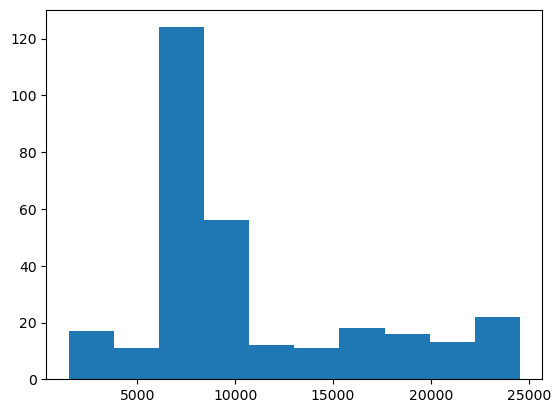

In [61]:
plt.hist(data["ArcMin"])

### Part 1: Redshift Distribution and Cluster Membership

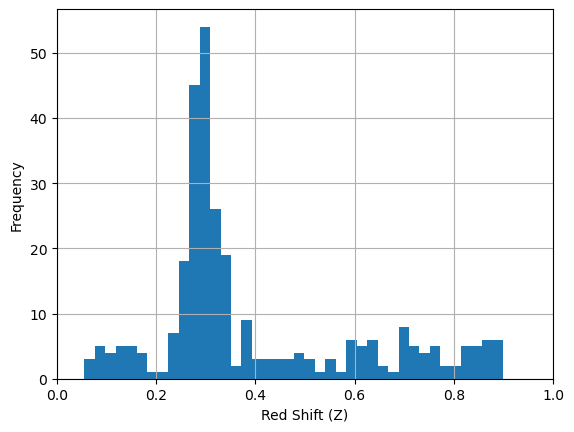

In [62]:
# TODO 1.1 Plot the redshift histogram of z all using 40 bins over [0, 1].
# Identify the cluster peak visually. Label axes and add a title.
n, bins, patches = plt.hist(data["z"],bins=40)
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
plt.xlim((0,1))
plt.grid("True")
plt.show()
sigma_N = np.sqrt(n)
sigma_N[sigma_N == 0] = 1.0


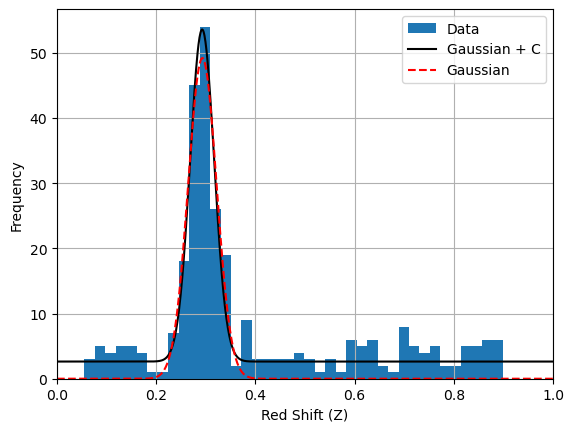

Gauss + C: Parameter: Z_cl: 0.2926034681439329 . Standar Deviation Error: 0.002688868838599602
Gauss + C: Parameter: Sigma_cl: 0.024204648846366597 . Standar Deviation Error: 0.002333877445583732
Gauss: Parameter: Z_cl: 0.2929984243771342 . Standar Deviation Error: 0.0041951862820614905
Gauss: Parameter: Sigma_cl: 0.02867633995106924 . Standar Deviation Error: 0.0031642950310759666


In [63]:
#Fit a Gaussian+background model to the cluster peak using MLE:
bins_center = 0.5*(bins[:-1] + bins[1:])

def gaussian_plus_background(z,A,z_cl,sigma_cl,C):
    return A* np.exp((-1*(z-z_cl)**2)/(2* sigma_cl**2)) + C


x= np.linspace(0,1,1000)
initial_guess_1=[50,0.3,0.001,5]
popt_bc, pcov_bc = curve_fit(gaussian_plus_background,bins_center,n,sigma=sigma_N,maxfev=100000,p0=initial_guess_1)
popt_nobc, pcov_nobc = curve_fit(model_1gauss,bins_center,n,sigma=sigma_N,maxfev=100000,p0=initial_guess_1[:-1])

plt.hist(data["z"],bins=40, label="Data")
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
plt.xlim((0,1))
plt.grid("True")
plt.plot(x,gaussian_plus_background(x, *popt_bc),label="Gaussian + C",color="black")
plt.plot(x,model_1gauss(x,*popt_nobc),label="Gaussian",color="red",ls="--")
plt.legend()
plt.show()
perr_bc = np.sqrt(np.diag(pcov_bc))
perr_nobc = np.sqrt(np.diag(pcov_nobc))

print("Gauss + C: Parameter: Z_cl: "+str(popt_bc[1])+" . Standar Deviation Error: "+str(perr_bc[1]))
print("Gauss + C: Parameter: Sigma_cl: "+str(popt_bc[2])+" . Standar Deviation Error: "+str(perr_bc[2]))
z_bc=popt_bc[1]
sigma_bc=popt_bc[2]
z_nobc=popt_nobc[1]
sigma_nobc=popt_nobc[2]
print("Gauss: Parameter: Z_cl: "+str(popt_nobc[1])+" . Standar Deviation Error: "+str(perr_nobc[1]))
print("Gauss: Parameter: Sigma_cl: "+str(popt_nobc[2])+" . Standar Deviation Error: "+str(perr_nobc[2]))


In [64]:
#Define cluster membership: a galaxy belongs to the cluster if |z − ẑcl| < 3σ̂cl.
#Count how many galaxies satisfy this criterion. Report the fraction of members vs. total.
sigmas=[3,2,1]
models=[[z_bc,sigma_bc],[z_nobc,sigma_nobc]]

for model in models:
    for i in sigmas:
        member_counter=0
        for j in data["z"]:
    #print(i)
            if np.abs(j - model[0]) < i*model[1]:
                member_counter+=1
        fracc=member_counter/len(data["z"])
        print("fraction of galaxies ("+str(member_counter)+") that belong to the cluster: "+str(fracc)+" for sigmas: "+str(i))

fraction of galaxies (171) that belong to the cluster: 0.57 for sigmas: 3
fraction of galaxies (160) that belong to the cluster: 0.5333333333333333 for sigmas: 2
fraction of galaxies (107) that belong to the cluster: 0.3566666666666667 for sigmas: 1
fraction of galaxies (175) that belong to the cluster: 0.5833333333333334 for sigmas: 3
fraction of galaxies (168) that belong to the cluster: 0.56 for sigmas: 2
fraction of galaxies (119) that belong to the cluster: 0.39666666666666667 for sigmas: 1


In [65]:
#Compute χ̃2 for the Gaussian+background fit. Is the fit acceptable?
# Compare with a single Gaussian (no C) and comment on the difference. (model1_gauss)

def chi2_val(model,num_params):
    sigma = np.sqrt(n)
    sigma[sigma == 0] = 1.0
    y_fit = model#gaussian_plus_background(centers, *popt)
    chi2 = float(np.sum(((n - y_fit)/sigma)**2))
    dof = len(n) - len(num_params)
    chi2_red = chi2/dof
    return chi2_red

popt, pcov = curve_fit(gaussian_plus_background,bins_center,n)
print("Curve fit: Gaussian + Background")
print(chi2_val(gaussian_plus_background(n,*popt),popt))
popt, pcov = curve_fit(model_1gauss,bins_center,n)
print("Curve fit: Gaussian")
print(chi2_val(model_1gauss(n,*popt),popt))

guess = [
    n.max(),                     # amplitude
    bins_center[np.argmax(n)],       # mean
    np.std(data["z"]),                # sigma
    n.min()                      # background
]

def chi2(params):
    model = gaussian_plus_background(bins_center, *params)
    sigma = np.sqrt(n)
    sigma[sigma == 0] = 1.0
    return np.sum(((n - model) / sigma)**2)

result = minimize(chi2, guess)

best_params = result.x
cov = result.hess_inv
errors = np.sqrt(np.diag(cov))
print("Minimize Chi Square: Gaussian + Background")
print(chi2_val(gaussian_plus_background(n,*best_params),best_params))
print("Z_cl = "+str(best_params[1])+" Hessian STD: "+ str(errors[1]))
print("Sigma_cl = "+str(best_params[2])+" Hessian STD: "+str(errors[2]))

def chi2_nobc(params):
    model = model_1gauss(bins_center, *params)
    sigma = np.sqrt(n)
    sigma[sigma == 0] = 1.0
    return np.sum(((n - model) / sigma)**2)

guess.pop()
result = minimize(chi2_nobc, guess)

best_params = result.x
cov = result.hess_inv
errors = np.sqrt(np.diag(cov))
print("Minimize Chi Square: Gaussian")
print(chi2_val(model_1gauss(n,*best_params),best_params))
print("Z_cl = "+str(best_params[1])+" Hessian STD: "+ str(errors[1]))
print("Sigma_cl = "+str(best_params[2])+" Hessian STD: "+str(errors[2]))

del popt, pcov, guess, result, best_params, sigmas



Curve fit: Gaussian + Background
5.257361849236051
Curve fit: Gaussian
8.108108108108109
Minimize Chi Square: Gaussian + Background
4.961972455516931
Z_cl = 0.2470551750791451 Hessian STD: 0.0006251794055945299
Sigma_cl = 0.005539181108298279 Hessian STD: 0.0003522257637162884
Minimize Chi Square: Gaussian
8.108108108108109
Z_cl = 0.25923539829735387 Hessian STD: 0.005614821169107325
Sigma_cl = 0.0023786181834214437 Hessian STD: 0.0037935579453617836


### Part 1.5: Data for Part 2 and 3 onward (maybe?)

In [66]:
data=pd.read_csv("BulletCluster_obs.csv")
bins=np.linspace(-8.25,8.25,34)
data["arc_min"] = 0.5*(bins[:-1] + bins[1:])

### Part 2: Profile Fitting

#### Galaxy Number Density

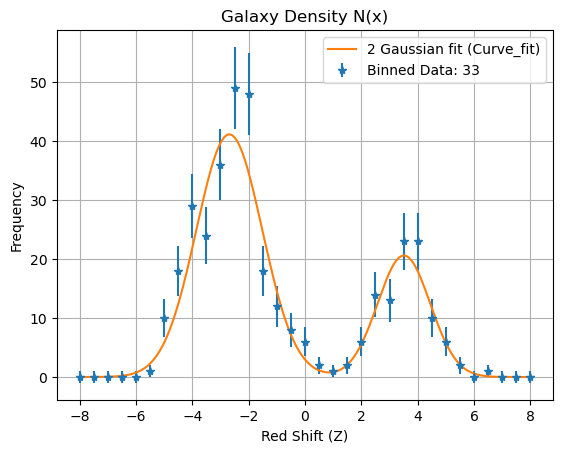

Parameter: mu1: -2.6860615661229987 . Standar Deviation Error: 0.07589038878325992
Parameter: mu2: 3.5084969943168693 . Standar Deviation Error: 0.09670024292911396


In [67]:
#Fit model 2gauss to N obs using curve fit
# Initial guess: A1 ≈ 45, µ1 ≈ −3, σ1 ≈ 1, A2 ≈ 20, µ2 ≈ 3, σ2 ≈ 1
# Store popt N, pcov N.
#x , A1 , mu1 , sig1 , A2 , mu2 , sig2
initial_guess=[45,-3,1,20,3,1]
#initial_guess=[110,0.31,0.035,15,0.69,0.07]
#bounds=(0, [3., 1., 0.5])
#bounds=((100,120),(0,1),(0,1),(5,20),(0,1),(0,1)])
#bounds=([100,0,0,5,0,0],[120,1,1,20,1,1])
x= np.linspace(-8,8,1000)
popt_N, pcov_N = curve_fit(model_2gauss,data["arc_min"],data["N_obs"],sigma=data["sigma_N"],p0=initial_guess,maxfev=100000)#,bounds=bounds)
#plt.hist(data["z"],bins=number_bins, label="Data")
plt.errorbar(data["arc_min"],data["N_obs"],yerr=data["sigma_N"],fmt="*",label="Binned Data: "+str(len(data["arc_min"])))
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
#plt.xlim((0,1))
plt.grid("True")
plt.plot(x,model_2gauss(x, *popt_N),label="2 Gaussian fit (Curve_fit)")
plt.legend()
plt.title("Galaxy Density N(x)")
plt.show()
perr_N = np.sqrt(np.diag(pcov_N))
print("Parameter: mu1: "+str(popt_N[1])+" . Standar Deviation Error: "+str(perr_N[1]))
print("Parameter: mu2: "+str(popt_N[4])+" . Standar Deviation Error: "+str(perr_N[4]))
#z_cl_N=popt_N[1]
#sigma_cl_N=popt_N[2]


In [68]:
#Compute χ̃2 χ̃2min and \nu
def chi2_val(data,model,num_params):
    #sigma = np.sqrt(data)
    #sigma[sigma == 0] = 1.0
    y_fit = model
    chi2 = float(np.sum(((data["N_obs"] - y_fit)/data["sigma_N"])**2))
    dof = len(data) - len(num_params)
    chi2_red = chi2/dof
    return chi2_red

print(chi2_val(data,model_2gauss(data["arc_min"],*popt_N),popt_N))


0.9593379037733131


In [69]:
def chi2_2gauss(params):
    return chi2_val(data,model_2gauss(data["arc_min"],*params),params)

#result = minimize(chi2_2gauss, initial_guess,method='Nelder-Mead', options={'xatol':1e-8,'fatol':1e-8,'maxiter':100000})
result = minimize(chi2_2gauss, initial_guess,method='BFGS', options={'maxiter':100000})
#result = minimize(chi2_2gauss, initial_guess,method='Powell', options={'maxiter':100000})
#result = minimize(chi2_2gauss, initial_guess,method='CG', options={'maxiter':100000})
#bounds=[(35,55),(-3,-2),(None,None),(15,30),(None,None),(None,None)]
#result = minimize(chi2_2gauss, initial_guess,method='L-BFGS-B',bounds=bounds, options={'maxiter':100000})
#result = minimize(chi2_2gauss, initial_guess,method='TNC', options={'maxiter':100000})

best_params_N = result.x
print("Minimized Chi Square: 2 Gaussians")
print(chi2_val(data,model_2gauss(data["arc_min"],*best_params_N),best_params_N))




Minimized Chi Square: 2 Gaussians
0.9593379037381013


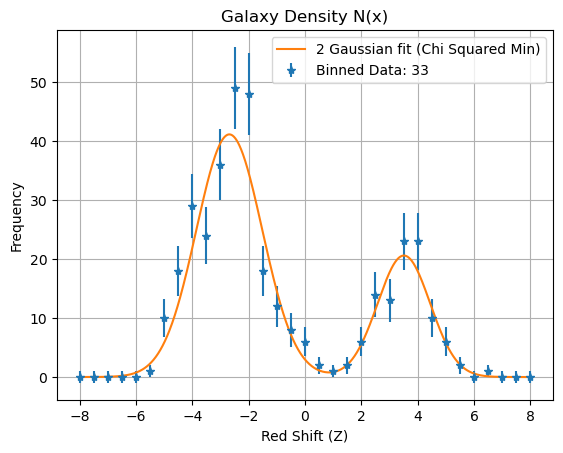

Parameter: mu1: -2.686061780418929
Parameter: mu2: 3.508499317975971


In [70]:
plt.errorbar(data["arc_min"],data["N_obs"],yerr=data["sigma_N"],fmt="*",label="Binned Data: "+str(len(data["arc_min"])))
plt.ylabel("Frequency")
plt.xlabel("Red Shift (Z)")
#plt.xlim((0,1))
plt.grid("True")
plt.plot(x,model_2gauss(x, *best_params_N),label="2 Gaussian fit (Chi Squared Min)")
plt.legend()
plt.title("Galaxy Density N(x)")
plt.show()
print("Parameter: mu1: "+str(best_params_N[1]))#+" . Standar Deviation Error: "+str(perr_N[1]))
print("Parameter: mu2: "+str(best_params_N[4]))

In [71]:
cov = result.hess_inv
errors = np.sqrt(np.diag(cov))
errors

array([11.56944817,  0.27264101,  0.20546368,  9.81718297,  0.34561371,
        0.29611971])

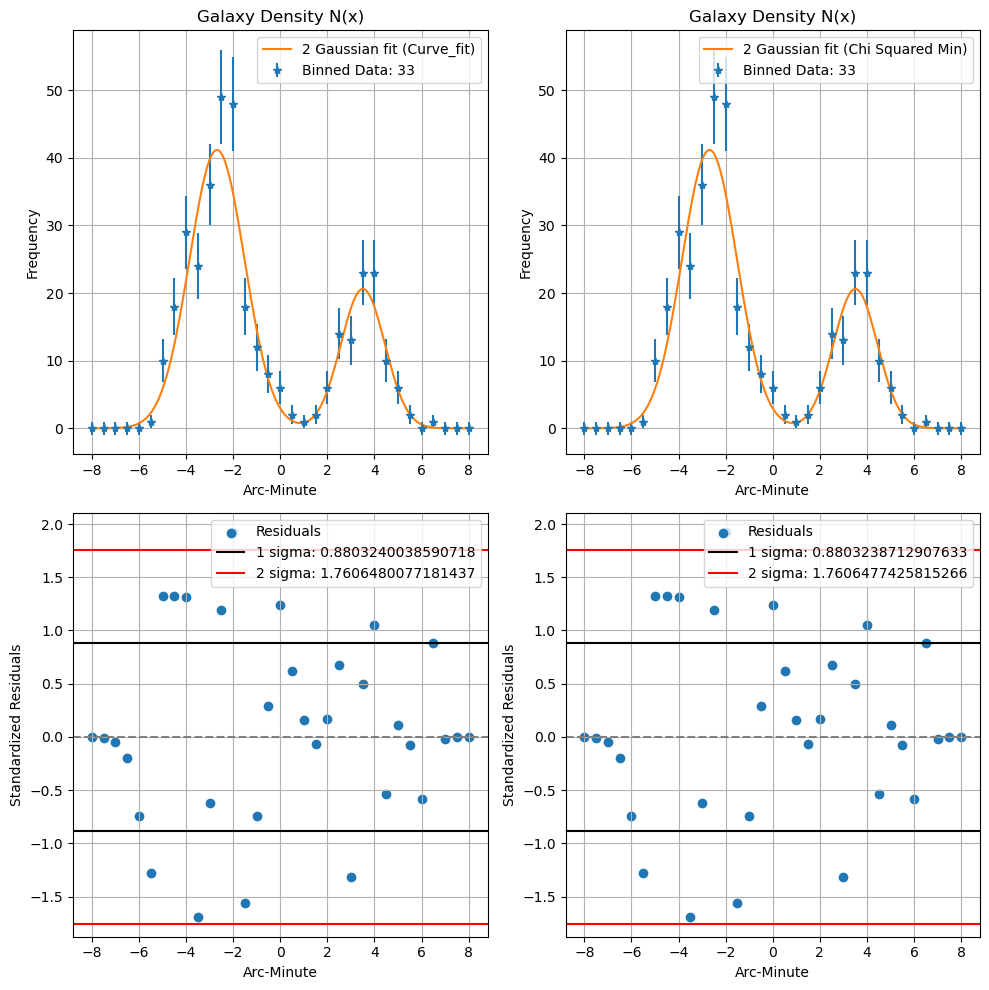

In [72]:
# 2.4: Three-panel figure
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0,0].errorbar(data["arc_min"],data["N_obs"],yerr=data["sigma_N"],fmt="*", label="Binned Data: "+str(len(data["arc_min"])))
axes[0,0].set_ylabel("Frequency")
axes[0,0].set_xlabel("Arc-Minute")
#axes[0].set_xlim((0,1))
axes[0,0].grid("True")
axes[0,0].plot(x,model_2gauss(x, *popt_N),label="2 Gaussian fit (Curve_fit)")
axes[0,0].legend()
axes[0,0].set_title("Galaxy Density N(x)")
axes[0,0].grid(True)
# Panel 2 — Residuals
#axes[1]: (mu_obs - mu_m3_fit) / sigma_i vs z
data["residual_N_curvefit"]= (data["N_obs"]-model_2gauss(data["arc_min"],*popt_N))/data["sigma_N"]
axes[1,0].scatter(data["arc_min"],data["residual_N_curvefit"],label="Residuals")
# Add horizontal lines at ±1, ±2 sigma
axes[1,0].axhline(np.std(data["residual_N_curvefit"]),color="black")
axes[1,0].axhline(-1*np.std(data["residual_N_curvefit"]),label="1 sigma: "+str(np.std(data["residual_N_curvefit"])),color="black")
axes[1,0].axhline(2*np.std(data["residual_N_curvefit"]),color="r",label="2 sigma: "+str(2*np.std(data["residual_N_curvefit"])))
axes[1,0].axhline(-2*np.std(data["residual_N_curvefit"]),color="r")
# Add horizontal line at 0
axes[1,0].axhline(0,ls="--",color="gray")
axes[1,0].legend()
axes[1,0].grid(True)
axes[1,0].set_xlabel("Arc-Minute")
axes[1,0].set_ylabel("Standardized Residuals")


axes[0,1].errorbar(data["arc_min"],data["N_obs"],yerr=data["sigma_N"],fmt="*", label="Binned Data: "+str(len(data["arc_min"])))
axes[0,1].set_ylabel("Frequency")
axes[0,1].set_xlabel("Arc-Minute")
#axes[0].set_xlim((0,1))
axes[0,1].grid("True")
axes[0,1].plot(x,model_2gauss(x, *best_params_N),label="2 Gaussian fit (Chi Squared Min)")
axes[0,1].legend()
axes[0,1].set_title("Galaxy Density N(x)")
axes[0,1].grid(True)
# Panel 2 — Residuals
#axes[1]: (mu_obs - mu_m3_fit) / sigma_i vs z
data["residual_N_minimize"]= (data["N_obs"]-model_2gauss(data["arc_min"],*best_params_N))/data["sigma_N"]
axes[1,1].scatter(data["arc_min"],data["residual_N_minimize"],label="Residuals")
# Add horizontal lines at ±1, ±2 sigma
axes[1,1].axhline(np.std(data["residual_N_minimize"]),color="black")
axes[1,1].axhline(-1*np.std(data["residual_N_minimize"]),label="1 sigma: "+str(np.std(data["residual_N_minimize"])),color="black")
axes[1,1].axhline(2*np.std(data["residual_N_minimize"]),color="r",label="2 sigma: "+str(2*np.std(data["residual_N_minimize"])))
axes[1,1].axhline(-2*np.std(data["residual_N_minimize"]),color="r")
# Add horizontal line at 0
axes[1,1].axhline(0,ls="--",color="gray")
axes[1,1].legend()
axes[1,1].grid(True)
axes[1,1].set_xlabel("Arc-Minute")
axes[1,1].set_ylabel("Standardized Residuals")
plt.tight_layout()
#plt.savefig('part2_chi2_fit.pdf')
plt.show()

#### X-ray surface brightness

In [73]:
data.keys()

Index(['N_source_obs', 'N_obs', 'sigma_N', 'SX', 'sigma_SX', 'kappa_obs',
       'arc_min', 'residual_N_curvefit', 'residual_N_minimize'],
      dtype='object')

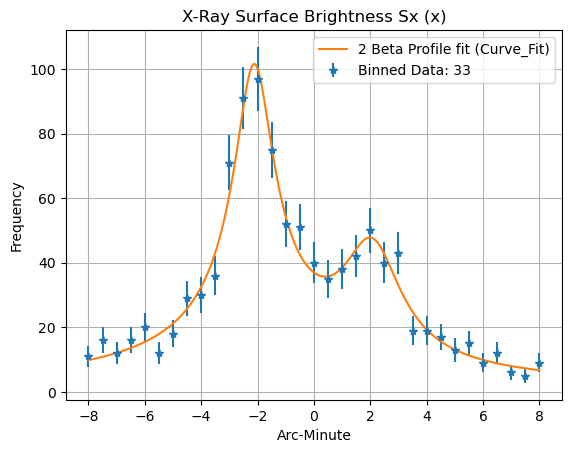

Parameter: x1: -2.1219612404460455 . Standar Deviation Error: 0.07296985430634235
Parameter: x2: 2.0652243587876535 . Standar Deviation Error: 0.15645732074150873


In [74]:
#Fit model 2beta to SXobs using curve fit
# Initial guess: S1 ≈ 80, x1 ≈ −2, r1 ≈ 1.5, β1 ≈ 0.8, S2 ≈ 35, x2 ≈ 2, r2 ≈ 1.0, β2 ≈ 0.7.
initial_guess_SX=[80,-2,1.5,0.8,35,2,1,0.7]
#initial_guess_SX=[110,0.31,0.5,80,15,0.69,1,70]
x= np.linspace(-8,8,1000)
popt_SX, pcov_SX = curve_fit(model_2beta,data["arc_min"],data["SX"],sigma=data["sigma_SX"],p0=initial_guess_SX,maxfev=100000)
#plt.hist(data["z"],bins=number_bins, label="Data")
plt.errorbar(data["arc_min"],data["SX"],yerr=data["sigma_SX"],fmt="*", label="Binned Data: "+str(len(data["arc_min"])))
plt.ylabel("Frequency")
plt.xlabel("Arc-Minute")
#plt.xlim((0,1))
plt.grid("True")
plt.title("X-Ray Surface Brightness Sx (x)")
plt.plot(x,model_2beta(x, *popt_SX),label="2 Beta Profile fit (Curve_Fit)")
plt.legend()
plt.show()
perr_SX = np.sqrt(np.diag(pcov_SX))
print("Parameter: x1: "+str(popt_SX[1])+" . Standar Deviation Error: "+str(perr_SX[1]))
print("Parameter: x2: "+str(popt_SX[5])+" . Standar Deviation Error: "+str(perr_SX[5]))



Chi Square Test Curve Fit:
0.8313421198896762
Minimized Chi Square: 2 Beta
0.8313421195426163


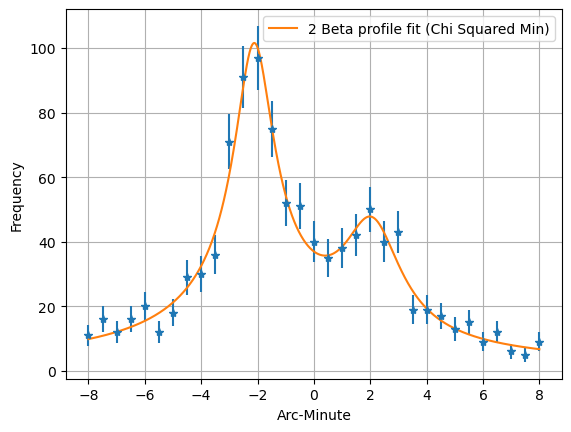

Parameter: x1: -2.1219671719447963
Parameter: x2: 2.0652150758251997


In [75]:
#Compute χ̃2 χ̃2min and \nu
def chi2_val(data,model,num_params):
    y_fit = model
    chi2 = float(np.sum(((data["SX"] - y_fit)/data["sigma_SX"])**2))
    dof = len(data) - len(num_params)
    chi2_red = chi2/dof
    return chi2_red
print("Chi Square Test Curve Fit:")
print(chi2_val(data,model_2beta(data["arc_min"],*popt_SX),popt_SX))

def chi2_2beta(params):
    return chi2_val(data,model_2beta(data["arc_min"],*params),params)

result = minimize(chi2_2beta, initial_guess_SX,method='BFGS', options={'maxiter':100000})
#result = minimize(chi2_2beta, initial_guess_SX,method='Nelder-Mead', options={'xatol':1e-8,'fatol':1e-8,'maxiter':100000})
#result = minimize(chi2_2beta, initial_guess_SX,method='Powell', options={'maxiter':100000})
#result = minimize(chi2_2beta, initial_guess_SX,method='CG', options={'maxiter':100000})
#result = minimize(chi2_2beta, initial_guess_SX,method='L-BFGS-B', options={'maxiter':100000})
#result = minimize(chi2_2beta, initial_guess_SX,method='TNC', options={'maxiter':100000})
#result = minimize(chi2_2beta, initial_guess_SX,method='Powell', options={'maxiter':100000})
best_params_SX = result.x
print("Minimized Chi Square: 2 Beta")
print(chi2_val(data,model_2beta(data["arc_min"],*best_params_SX),best_params_SX))

#x= np.linspace(0,1,1000)
plt.errorbar(data["arc_min"],data["SX"],yerr=data["sigma_SX"],fmt="*")
plt.ylabel("Frequency")
plt.xlabel("Arc-Minute")
#plt.xlim((0,1))
plt.grid("True")
plt.plot(x,model_2beta(x, *best_params_SX),label="2 Beta profile fit (Chi Squared Min)")
plt.legend()
plt.show()
print("Parameter: x1: "+str(best_params_SX[1]))#+" . Standar Deviation Error: "+str(perr_N[1]))
print("Parameter: x2: "+str(best_params_SX[5]))


In [76]:
cov = result.hess_inv
errors = np.sqrt(np.diag(cov))
errors

array([31.38547656,  0.30117075,  0.60875329,  0.32406661, 21.47662184,
        0.61091096,  2.5318573 ,  2.10586455])

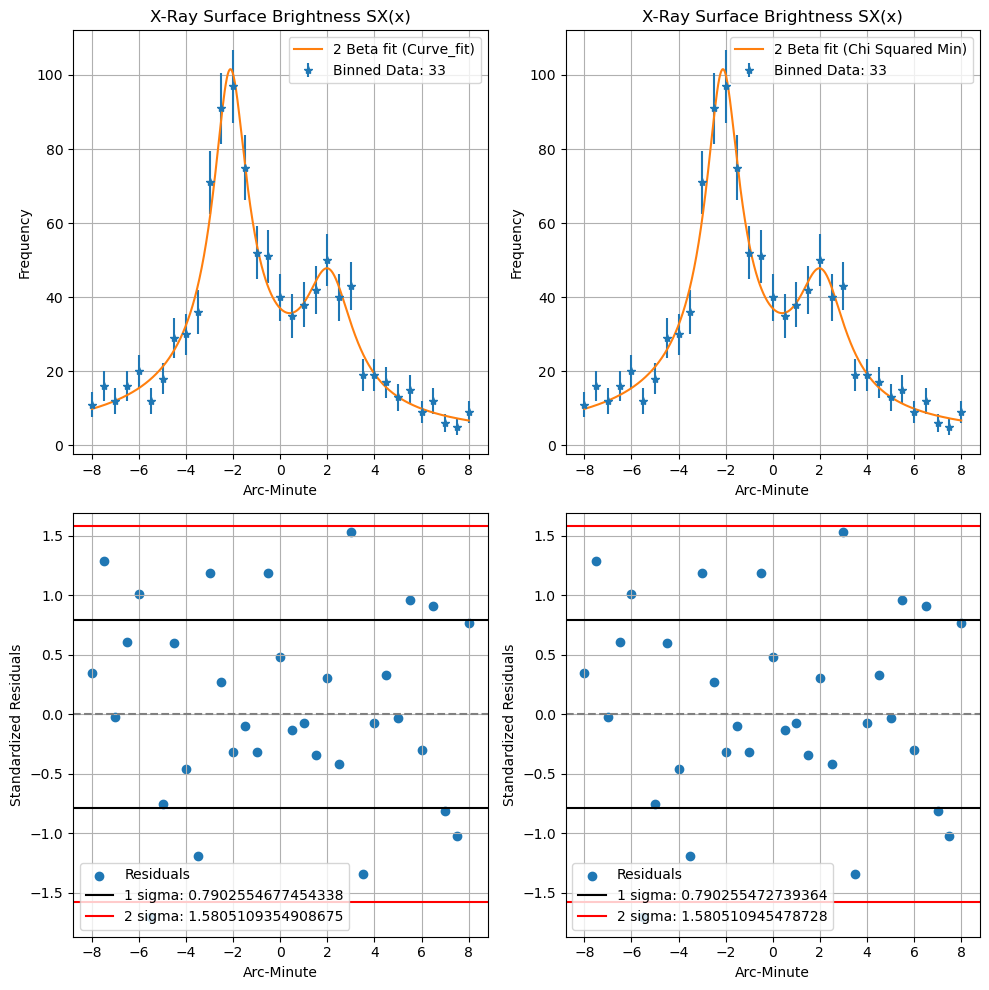

In [77]:
# 2.4: Three-panel figure
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0,0].errorbar(data["arc_min"],data["SX"],yerr=data["sigma_SX"],fmt="*", label="Binned Data: "+str(len(data["arc_min"])))
axes[0,0].set_ylabel("Frequency")
axes[0,0].set_xlabel("Arc-Minute")
#axes[0].set_xlim((0,1))
axes[0,0].grid("True")
axes[0,0].plot(x,model_2beta(x, *popt_SX),label="2 Beta fit (Curve_fit)")
axes[0,0].legend()
axes[0,0].set_title("X-Ray Surface Brightness SX(x)")
axes[0,0].grid(True)
# Panel 2 — Residuals
#axes[1]: (mu_obs - mu_m3_fit) / sigma_i vs z
data["residual_SX_curvefit"]= (data["SX"]-model_2beta(data["arc_min"],*popt_SX))/data["sigma_SX"]
axes[1,0].scatter(data["arc_min"],data["residual_SX_curvefit"],label="Residuals")
# Add horizontal lines at ±1, ±2 sigma
axes[1,0].axhline(np.std(data["residual_SX_curvefit"]),color="black")
axes[1,0].axhline(-1*np.std(data["residual_SX_curvefit"]),label="1 sigma: "+str(np.std(data["residual_SX_curvefit"])),color="black")
axes[1,0].axhline(2*np.std(data["residual_SX_curvefit"]),color="r",label="2 sigma: "+str(2*np.std(data["residual_SX_curvefit"])))
axes[1,0].axhline(-2*np.std(data["residual_SX_curvefit"]),color="r")
# Add horizontal line at 0
axes[1,0].axhline(0,ls="--",color="gray")
axes[1,0].legend()
axes[1,0].grid(True)
axes[1,0].set_xlabel("Arc-Minute")
axes[1,0].set_ylabel("Standardized Residuals")


axes[0,1].errorbar(data["arc_min"],data["SX"],yerr=data["sigma_SX"],fmt="*", label="Binned Data: "+str(len(data["arc_min"])))
axes[0,1].set_ylabel("Frequency")
axes[0,1].set_xlabel("Arc-Minute")
#axes[0].set_xlim((0,1))
axes[0,1].grid("True")
axes[0,1].plot(x,model_2beta(x, *best_params_SX),label="2 Beta fit (Chi Squared Min)")
axes[0,1].legend()
axes[0,1].set_title("X-Ray Surface Brightness SX(x)")
axes[0,1].grid(True)
# Panel 2 — Residuals
#axes[1]: (mu_obs - mu_m3_fit) / sigma_i vs z
data["residual_SX_minimize"]= (data["SX"]-model_2beta(data["arc_min"],*best_params_SX))/data["sigma_SX"]
axes[1,1].scatter(data["arc_min"],data["residual_SX_minimize"],label="Residuals")
# Add horizontal lines at ±1, ±2 sigma
axes[1,1].axhline(np.std(data["residual_SX_minimize"]),color="black")
axes[1,1].axhline(-1*np.std(data["residual_SX_minimize"]),label="1 sigma: "+str(np.std(data["residual_SX_minimize"])),color="black")
axes[1,1].axhline(2*np.std(data["residual_SX_minimize"]),color="r",label="2 sigma: "+str(2*np.std(data["residual_SX_minimize"])))
axes[1,1].axhline(-2*np.std(data["residual_SX_minimize"]),color="r")
# Add horizontal line at 0
axes[1,1].axhline(0,ls="--",color="gray")
axes[1,1].legend()
axes[1,1].grid(True)
axes[1,1].set_xlabel("Arc-Minute")
axes[1,1].set_ylabel("Standardized Residuals")
plt.tight_layout()
#plt.savefig('part2_chi2_fit.pdf')
plt.show()

#### Lensing Convergence

In [78]:
data.keys()

Index(['N_source_obs', 'N_obs', 'sigma_N', 'SX', 'sigma_SX', 'kappa_obs',
       'arc_min', 'residual_N_curvefit', 'residual_N_minimize',
       'residual_SX_curvefit', 'residual_SX_minimize'],
      dtype='object')

In [79]:
#Calculate the Sigma_Kappa
def sigma_kappa(data,sigma_epsilon = 0.30):
#sigma_kappa=sigma_epsilon/ Number of galaxy - 1 per bin
    a=[]
    for i in data["N_source_obs"]:

        if i <=0:
            a.append(sigma_epsilon)
        else:
            a.append(sigma_epsilon/np.sqrt(i))
    data["sigma_kappa"]=a
    del a

sigma_kappa(data)



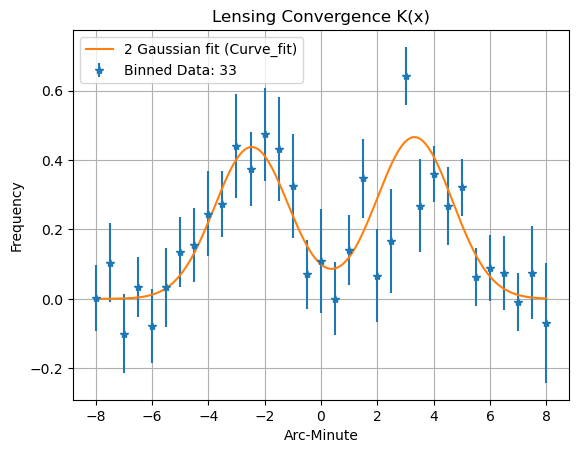

Parameter: mu1: -2.460567082379332 . Standar Deviation Error: 0.2265557198270667
Parameter: mu2: 3.3151101093589954 . Standar Deviation Error: 0.18984348909797838


In [80]:
initial_guess_k=[0.42,-3,1.4,0.35,3,1.3]
x= np.linspace(-8,8,1000)
popt_k, pcov_k = curve_fit(model_2gauss,data["arc_min"],data["kappa_obs"],sigma=data["sigma_kappa"],p0=initial_guess_k,maxfev=100000,nan_policy="omit")#,bounds=bounds)
plt.errorbar(data["arc_min"],data["kappa_obs"],yerr=data["sigma_kappa"],fmt="*",label="Binned Data: "+str(len(data["arc_min"])))
plt.ylabel("Frequency")
plt.xlabel("Arc-Minute")
#plt.ylim(-0.4,0.6)
plt.grid("True")
plt.plot(x,model_2gauss(x, *popt_k),label="2 Gaussian fit (Curve_fit)")
plt.legend()
plt.title("Lensing Convergence K(x)")
plt.show()
perr_k = np.sqrt(np.diag(pcov_k))
print("Parameter: mu1: "+str(popt_k[1])+" . Standar Deviation Error: "+str(perr_k[1]))
print("Parameter: mu2: "+str(popt_k[4])+" . Standar Deviation Error: "+str(perr_k[4]))
#z_cl_N=popt_N[1]
#sigma_cl_N=popt_N[2]


In [81]:
#Compute χ̃2 χ̃2min and \nu
def chi2_val(data,model,num_params):
    #sigma = np.sqrt(data)
    #sigma[sigma == 0] = 1.0
    y_fit = model
    chi2 = float(np.sum(((data["kappa_obs"] - y_fit)/data["sigma_kappa"])**2))
    dof = len(data) - len(num_params)
    chi2_red = chi2/dof
    return chi2_red

print(chi2_val(data,model_2gauss(data["arc_min"],*popt_k),popt_k))


0.8796472251943236


In [82]:
def chi2_2gauss(params):
    return chi2_val(data,model_2gauss(data["arc_min"],*params),params)

#result = minimize(chi2_2gauss, initial_guess_k,method='Nelder-Mead', options={'xatol':1e-8,'fatol':1e-8,'maxiter':100000})
#result = minimize(chi2_2gauss, initial_guess_k,method='BFGS', options={'maxiter':100000})
#result = minimize(chi2_2gauss, initial_guess_k,method='Powell', options={'maxiter':100000})
#result = minimize(chi2_2gauss, initial_guess_k,method='CG', options={'maxiter':100000})
bounds=[(0.3,0.6),(-3,-2),(None,None),(0.1,0.5),(3,5),(None,None)]
result = minimize(chi2_2gauss, initial_guess_k,method='L-BFGS-B',bounds=bounds, options={'maxiter':100000})
#result = minimize(chi2_2gauss, initial_guess,method='TNC', options={'maxiter':100000})

best_params_k = result.x
print("Minimized Chi Square: 2 Gaussians")
print(chi2_val(data,model_2gauss(data["arc_min"],*best_params_k),best_params_k))




Minimized Chi Square: 2 Gaussians
0.8796472249291599


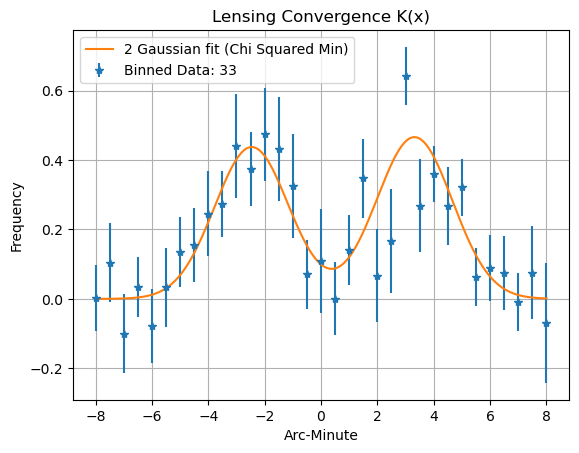

Parameter: mu1: -2.4605761882570896
Parameter: mu2: 3.3151052321536447


In [83]:
plt.errorbar(data["arc_min"],data["kappa_obs"],yerr=data["sigma_kappa"],fmt="*",label="Binned Data: "+str(len(data["arc_min"])))
plt.ylabel("Frequency")
plt.xlabel("Arc-Minute")
#plt.ylim(-0.4,0.6)
plt.grid("True")
plt.plot(x,model_2gauss(x, *best_params_k),label="2 Gaussian fit (Chi Squared Min)")
plt.legend()
plt.title("Lensing Convergence K(x)")
plt.show()
print("Parameter: mu1: "+str(best_params_k[1]))#+" . Standar Deviation Error: "+str(perr_N[1]))
print("Parameter: mu2: "+str(best_params_k[4]))

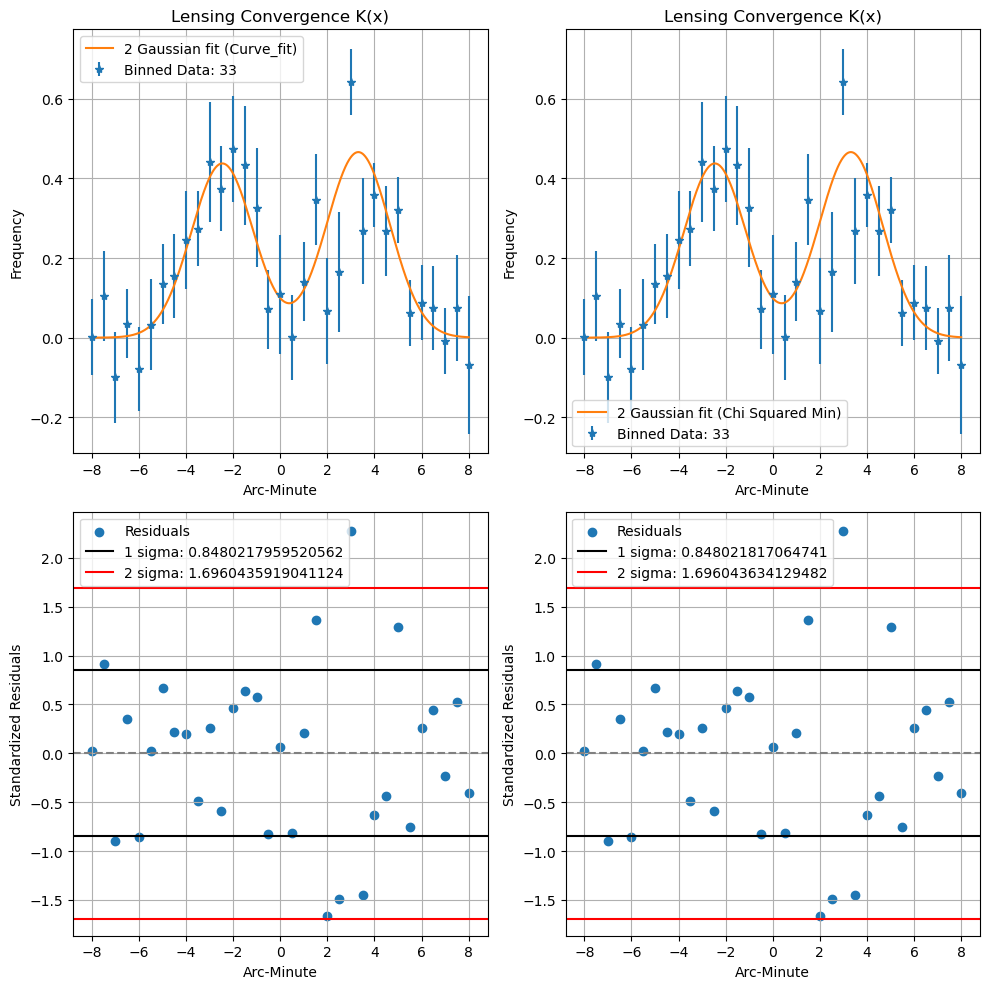

In [84]:
# 2.4: Three-panel figure
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0,0].errorbar(data["arc_min"],data["kappa_obs"],yerr=data["sigma_kappa"],fmt="*", label="Binned Data: "+str(len(data["arc_min"])))
axes[0,0].set_ylabel("Frequency")
axes[0,0].set_xlabel("Arc-Minute")
#axes[0].set_xlim((0,1))
axes[0,0].grid("True")
axes[0,0].plot(x,model_2gauss(x, *popt_k),label="2 Gaussian fit (Curve_fit)")
axes[0,0].legend()
axes[0,0].set_title("Lensing Convergence K(x)")
axes[0,0].grid(True)
#axes[0,0].set_ylim(-0.4,0.6)
# Panel 2 — Residuals
#axes[1]: (mu_obs - mu_m3_fit) / sigma_i vs z
data["residual_k_curvefit"]= (data["kappa_obs"]-model_2gauss(data["arc_min"],*popt_k))/data["sigma_kappa"]
axes[1,0].scatter(data["arc_min"],data["residual_k_curvefit"],label="Residuals")
# Add horizontal lines at ±1, ±2 sigma
axes[1,0].axhline(np.std(data["residual_k_curvefit"]),color="black")
axes[1,0].axhline(-1*np.std(data["residual_k_curvefit"]),label="1 sigma: "+str(np.std(data["residual_k_curvefit"])),color="black")
axes[1,0].axhline(2*np.std(data["residual_k_curvefit"]),color="r",label="2 sigma: "+str(2*np.std(data["residual_k_curvefit"])))
axes[1,0].axhline(-2*np.std(data["residual_k_curvefit"]),color="r")
# Add horizontal line at 0
axes[1,0].axhline(0,ls="--",color="gray")
axes[1,0].legend()
axes[1,0].grid(True)
axes[1,0].set_xlabel("Arc-Minute")
axes[1,0].set_ylabel("Standardized Residuals")


axes[0,1].errorbar(data["arc_min"],data["kappa_obs"],yerr=data["sigma_kappa"],fmt="*", label="Binned Data: "+str(len(data["arc_min"])))
axes[0,1].set_ylabel("Frequency")
axes[0,1].set_xlabel("Arc-Minute")
#axes[0].set_xlim((0,1))
axes[0,1].grid("True")
axes[0,1].plot(x,model_2gauss(x, *best_params_k),label="2 Gaussian fit (Chi Squared Min)")
axes[0,1].legend()
axes[0,1].set_title("Lensing Convergence K(x)")
axes[0,1].grid(True)
#axes[0,1].set_ylim(-0.4,0.6)
# Panel 2 — Residuals
#axes[1]: (mu_obs - mu_m3_fit) / sigma_i vs z
data["residual_k_minimize"]= (data["kappa_obs"]-model_2gauss(data["arc_min"],*best_params_k))/data["sigma_kappa"]
axes[1,1].scatter(data["arc_min"],data["residual_k_minimize"],label="Residuals")
# Add horizontal lines at ±1, ±2 sigma
axes[1,1].axhline(np.std(data["residual_k_minimize"]),color="black")
axes[1,1].axhline(-1*np.std(data["residual_k_minimize"]),label="1 sigma: "+str(np.std(data["residual_k_minimize"])),color="black")
axes[1,1].axhline(2*np.std(data["residual_k_minimize"]),color="r",label="2 sigma: "+str(2*np.std(data["residual_k_minimize"])))
axes[1,1].axhline(-2*np.std(data["residual_k_minimize"]),color="r")
# Add horizontal line at 0
axes[1,1].axhline(0,ls="--",color="gray")
axes[1,1].legend()
axes[1,1].grid(True)
axes[1,1].set_xlabel("Arc-Minute")
axes[1,1].set_ylabel("Standardized Residuals")
plt.tight_layout()
#plt.savefig('part2_chi2_fit.pdf')
plt.show()

### Part 3 Residual Diagnostic
Estan todos en el dataframe Data

#### Z Test

In [85]:
alpha = 0.05
n = len(data['residual_N_minimize'])
z_uncorrected = normdist.ppf(1-alpha/2)
z_bonf = normdist.ppf(1-alpha/(2*n))

print(f'Uncorrected threshold: {z_uncorrected}')
print(f'Bonferroni correction: {z_bonf}')

Uncorrected threshold: 1.959963984540054
Bonferroni correction: 3.1717657833516224


In [86]:
def Z_test(res, data=data, z_un=z_uncorrected, z_bon=z_bonf, n=n):
    out_unc = np.sum(np.abs(data[res]) > z_un)
    out_bonf = np.sum(np.abs(data[res]) > z_bon)

    plt.figure(figsize=(10, 4))
    plt.bar(np.arange(n), data[res])
    plt.axhline(z_un, color='red', ls='--', label='95%')
    plt.axhline(-z_un, color='red', ls='--')
    plt.axhline(z_bon, color='green', ls=':')
    plt.axhline(-z_bon, color='green', ls=':')
    plt.title(f'Z test: {res}')
    plt.xlabel('Bin')
    plt.ylabel('Standarized residual')
    plt.text(-0.8, z_un+0.05, f"Outliers uncorrected: {out_unc}")
    plt.text(-0.8, z_bon+0.05, f"Outliers Bonferroni: {out_bonf}")
    plt.legend()
    plt.show()

    return out_unc, out_bonf

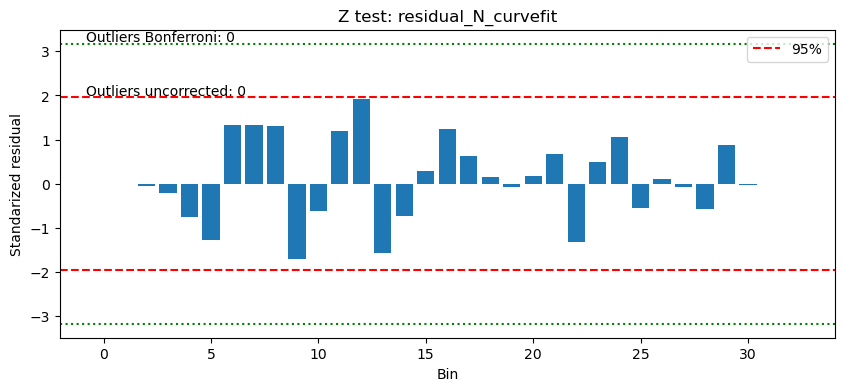

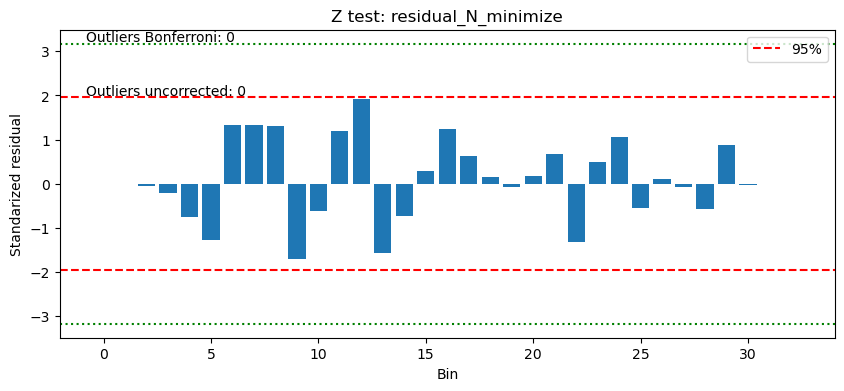

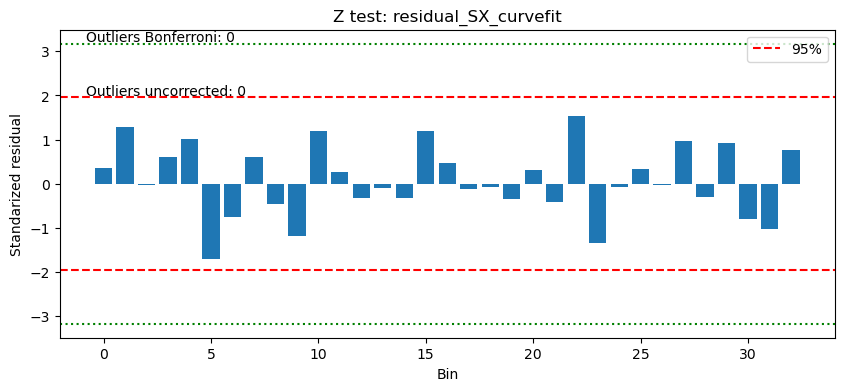

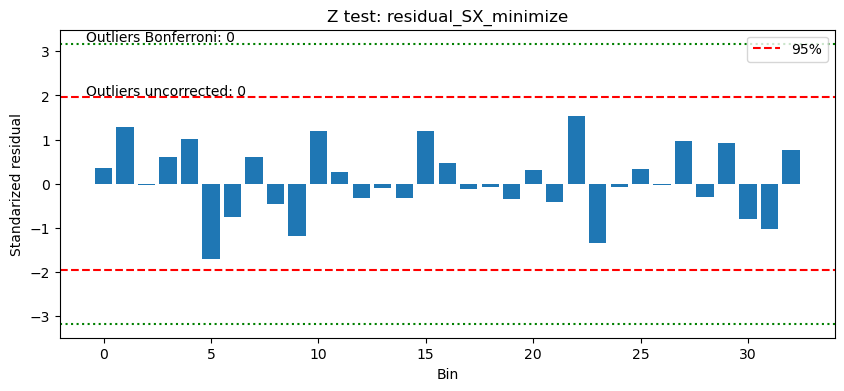

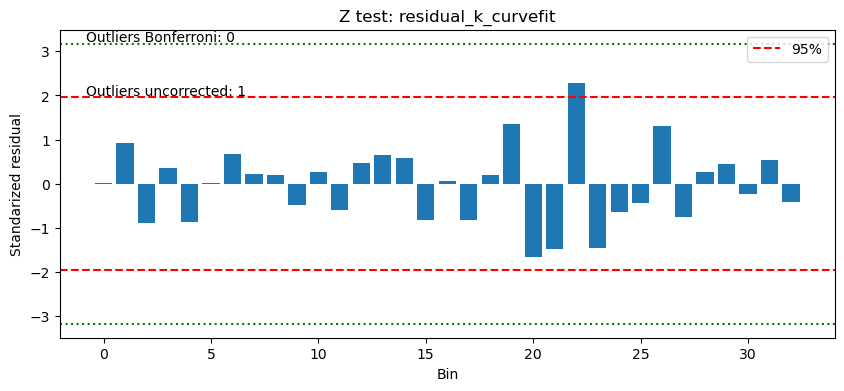

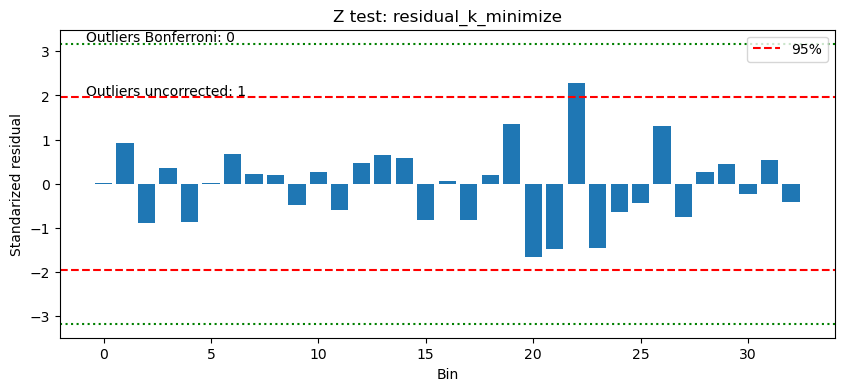

In [87]:
Z_N_curv = Z_test('residual_N_curvefit')
Z_N_min = Z_test('residual_N_minimize')
Z_SX_curv = Z_test('residual_SX_curvefit')
Z_SX_min = Z_test('residual_SX_minimize')
Z_k_curv = Z_test('residual_k_curvefit')
Z_k_min = Z_test('residual_k_minimize')

#### T Test

In [88]:
def T_test(res, data=data, n=n):
    rbar = np.mean(data[res])
    Sr = np.std(data[res], ddof=1)
    t = rbar/(Sr/np.sqrt(n))
    p = 2*(1 - tdist.cdf(abs(t), df=n-1))

    print('\n-----------------------------------')
    print(f'T test: {res}')
    print(f't: {t}')
    print(f'p: {p}')

    if p < 0.05:
        print('Systematic bias')
    else:
        print('No systematic bias')

    return (t, p)

In [89]:
T_N_curv = T_test('residual_N_curvefit')
T_N_min = T_test('residual_N_minimize')
T_SX_curv = T_test('residual_SX_curvefit')
T_SX_min = T_test('residual_SX_minimize')
T_k_curv = T_test('residual_k_curvefit')
T_k_min = T_test('residual_k_minimize')


-----------------------------------
T test: residual_N_curvefit
t: 0.6407369615432387
p: 0.526255861187932
No systematic bias

-----------------------------------
T test: residual_N_minimize
t: 0.6407445779179018
p: 0.5262509752798419
No systematic bias

-----------------------------------
T test: residual_SX_curvefit
t: 0.5211750244824597
p: 0.605833172501621
No systematic bias

-----------------------------------
T test: residual_SX_minimize
t: 0.5211746202551589
p: 0.6058334508601964
No systematic bias

-----------------------------------
T test: residual_k_curvefit
t: -0.15931534296681324
p: 0.8744217388982096
No systematic bias

-----------------------------------
T test: residual_k_minimize
t: -0.15931030794592363
p: 0.8744256731999589
No systematic bias


#### Run Test

In [90]:
def Run_test(res, data=data):
    signs = data[res] > 0

    R = 1
    for i in range(1, len(signs)):
        if signs[i] != signs[i-1]:
            R += 1

    n_plus = np.sum(signs)
    n_minus = len(signs) - n_plus

    E = 2*n_plus*n_minus/(n_plus+n_minus)+1

    Var = (2*n_plus*n_minus*(2*n_plus*n_minus-n_plus-n_minus))/(((n_plus+n_minus)**2)*(n_plus+n_minus-1))

    Zrun = (R-E)/np.sqrt(Var)

    p = 2*(1-normdist.cdf(abs(Zrun)))

    print('\n--------------------------------')
    print(f'Run Test: {res}')
    print(f'Runs: {R}')
    print(f'E[R]: {E}')
    print(f'Zrun: {Zrun}')
    print(f'p: {p}')

    return R, Zrun, p

In [91]:
Run_N_curv = Run_test('residual_N_curvefit')
Run_N_min = Run_test('residual_N_minimize')
Run_SX_curv = Run_test('residual_SX_curvefit')
Run_SX_min = Run_test('residual_SX_minimize')
Run_k_curv = Run_test('residual_k_curvefit')
Run_k_min = Run_test('residual_k_minimize')


--------------------------------
Run Test: residual_N_curvefit
Runs: 15
E[R]: 17.363636363636363
Zrun: -0.8432740427115677
p: 0.3990751965482373

--------------------------------
Run Test: residual_N_minimize
Runs: 15
E[R]: 17.363636363636363
Zrun: -0.8432740427115677
p: 0.3990751965482373

--------------------------------
Run Test: residual_SX_curvefit
Runs: 21
E[R]: 17.363636363636363
Zrun: 1.2973446810947198
p: 0.19451261718561175

--------------------------------
Run Test: residual_SX_minimize
Runs: 21
E[R]: 17.363636363636363
Zrun: 1.2973446810947198
p: 0.19451261718561175

--------------------------------
Run Test: residual_k_curvefit
Runs: 22
E[R]: 17.12121212121212
Zrun: 1.767643889280957
p: 0.07712045585335225

--------------------------------
Run Test: residual_k_minimize
Runs: 22
E[R]: 17.12121212121212
Zrun: 1.767643889280957
p: 0.07712045585335225


#### F Test

In [92]:
def F_test(chi2_1, chi2_2, k1, k2, n):
    nu2 = n - k2
    F = ((chi2_1 - chi2_2)/(k2 - k1)/(chi2_2/nu2))
    p = 1 - fdist.cdf(F, k2 - k1, nu2)

    print(f'Chi2 1 component: {chi2_1}')
    print(f'Chi2 2 components: {chi2_2}')
    print(f'F: {F}')
    print(f'p: {p}')

    if p < 0.05:
        print('Two component model is significantly better')
    else:
        print('Two component model is not significantly better')

    return F, p

##### Galaxias

In [93]:
initial_guess_1N = [45, -3, 1]

popt_1N, pcov_1N = curve_fit(
    model_1gauss,
    data['arc_min'],
    data['N_obs'],
    sigma=data['sigma_N'],
    p0=initial_guess_1N,
    absolute_sigma=True,
    maxfev=100000
)

chi2_1N = np.sum(
    ((data['N_obs'] - model_1gauss(data['arc_min'], *popt_1N))
     /data['sigma_N'])**2
)
chi2_2N = np.sum(
    ((data["N_obs"] - model_2gauss(data["arc_min"], *popt_N))
     / data["sigma_N"])**2
)

In [94]:
F_N, pF_N = F_test(
    chi2_1N,
    chi2_2N,
    len(popt_1N),
    len(popt_N),
    len(data)
)

Chi2 1 component: 121.29748230122638
Chi2 2 components: 25.902123401879454
F: 33.146248929994115
p: 3.3827884937664976e-09
Two component model is significantly better


##### X-Ray

In [95]:
initial_guess_1SX = [80, -2, 1.5, 0.8]

popt_1SX, pcov_1SX = curve_fit(
    model_1beta,
    data["arc_min"],
    data["SX"],
    sigma=data["sigma_SX"],
    p0=initial_guess_1SX,
    absolute_sigma=True,
    maxfev=100000
)

chi2_1SX = np.sum(
    ((data["SX"] - model_1beta(data["arc_min"], *popt_1SX))
     / data["sigma_SX"])**2
)

chi2_2SX = np.sum(
    ((data["SX"] - model_2beta(data["arc_min"], *popt_SX))
     / data["sigma_SX"])**2
)

In [96]:
F_SX, pF_SX = F_test(
    chi2_1SX,
    chi2_2SX,
    len(popt_1SX),
    len(popt_SX),
    len(data)
)

Chi2 1 component: 92.4332859402065
Chi2 2 components: 20.783552997241905
F: 21.5464040702259
p: 8.464381284767342e-08
Two component model is significantly better


##### Lensing

In [97]:
initial_guess_1k = [0.42, -3, 1.4]

popt_1k, pcov_1k = curve_fit(
    model_1gauss,
    data["arc_min"],
    data["kappa_obs"],
    sigma=data["sigma_kappa"],
    p0=initial_guess_1k,
    absolute_sigma=True,
    maxfev=100000
)

chi2_1k = np.sum(
    ((data["kappa_obs"] - model_1gauss(data["arc_min"], *popt_1k))
     / data["sigma_kappa"])**2
)

chi2_2k = np.sum(
    ((data["kappa_obs"] - model_2gauss(data["arc_min"], *popt_k))
     / data["sigma_kappa"])**2
)

In [98]:
F_k, pF_k = F_test(
    chi2_1k,
    chi2_2k,
    len(popt_1k),
    len(popt_k),
    len(data)
)

Chi2 1 component: 66.73415722799402
Chi2 2 components: 23.750475080246737
F: 16.28822741535268
p: 3.0535718202884254e-06
Two component model is significantly better


#### Pearson

In [99]:
def Pearson_test(residuals, alpha=0.05, k=6):
    residuals = np.asarray(residuals)

    n = len(residuals)
    mu = np.mean(residuals)
    sigma = np.std(residuals, ddof=0)

    E = n / k
    while E < 5 and k > 3:
        k -= 1
        E = n / k

    probabilities = np.linspace(0, 1, k + 1)
    boundaries = normdist.ppf(probabilities, loc=mu, scale=sigma)
    O, _ = np.histogram(residuals, bins=boundaries)
    expected = np.full(k, E)

    chi2_P = np.sum((O - expected)**2 / expected)
    p_parameters = 2
    dof = k - 1 - p_parameters
    p_value = 1 - chi2dist.cdf(chi2_P, dof)

    print(f'n = {n}')
    print(f'mu = {mu:.4f}')
    print(f'sigma = {sigma:.4f}')
    print(f'k = {k}')
    print(f'Expected count per bin = {E:.4f}')
    print(f'Observed counts = {O}')
    print(f'Chi-square = {chi2_P:.4f}')
    print(f'dof = {dof}')
    print(f'p-value = {p_value:.6f}')

    if p_value < alpha:
        print('Reject Gaussianity')
    else:
        print('Fail to reject Gaussianity')

    return chi2_P, p_value

In [100]:
print('GALAXIES - CURVE FIT')
chi2Pearson_N_curvefit, pPearson_N_curvefit = Pearson_test(
    data["residual_N_curvefit"]
)
print('\nGALAXIES - MINIMIZE')
chi2Pearson_N_minimize, pPearson_N_minimize = Pearson_test(
    data["residual_N_minimize"]
)
print('\nX-RAY - CURVE FIT')
chi2Pearson_SX_curvefit, pPearson_SX_curvefit = Pearson_test(
    data["residual_SX_curvefit"]
)
print('\nX-RAY - MINIMIZE')
chi2Pearson_SX_minimize, pPearson_SX_minimize = Pearson_test(
    data["residual_SX_minimize"]
)
print('\nLENSING - CURVE FIT')
chi2Pearson_k_curvefit, pPearson_k_curvefit = Pearson_test(
    data["residual_k_curvefit"]
)
print('\nLENSING - MINIMIZE')
chi2Pearson_k_minimize, pPearson_k_minimize = Pearson_test(
    data["residual_k_minimize"]
)

GALAXIES - CURVE FIT
n = 33
mu = 0.0997
sigma = 0.8803
k = 6
Expected count per bin = 5.5000
Observed counts = [4 5 9 4 4 7]
Chi-square = 3.9091
dof = 3
p-value = 0.271449
Fail to reject Gaussianity

GALAXIES - MINIMIZE
n = 33
mu = 0.0997
sigma = 0.8803
k = 6
Expected count per bin = 5.5000
Observed counts = [4 5 9 4 4 7]
Chi-square = 3.9091
dof = 3
p-value = 0.271449
Fail to reject Gaussianity

X-RAY - CURVE FIT
n = 33
mu = 0.0728
sigma = 0.7903
k = 6
Expected count per bin = 5.5000
Observed counts = [6 6 6 4 4 7]
Chi-square = 1.3636
dof = 3
p-value = 0.714080
Fail to reject Gaussianity

X-RAY - MINIMIZE
n = 33
mu = 0.0728
sigma = 0.7903
k = 6
Expected count per bin = 5.5000
Observed counts = [6 6 6 4 4 7]
Chi-square = 1.3636
dof = 3
p-value = 0.714080
Fail to reject Gaussianity

LENSING - CURVE FIT
n = 33
mu = -0.0239
sigma = 0.8480
k = 6
Expected count per bin = 5.5000
Observed counts = [5 8 1 8 7 4]
Chi-square = 6.8182
dof = 3
p-value = 0.077924
Fail to reject Gaussianity

LENSING 

#### Lilliefors

In [101]:
def Lilliefors_test(residuals, B=5000, alpha=0.05, seed=42):
    residuals = np.asarray(residuals)
    n = len(residuals)
    mu = np.mean(residuals)
    sigma = np.std(residuals, ddof=0)
    D_obs, p_KS = kstest(
        residuals,
        'norm',
        args=(mu, sigma)
    )
    rng = np.random.default_rng(seed)
    D_sim = np.zeros(B)

    for b in range(B):
        simulated = rng.normal(
            loc=mu,
            scale=sigma,
            size=n
        )
        mu_b = np.mean(simulated)
        sigma_b = np.std(simulated, ddof=0)
        D_sim[b], _ = kstest(
            simulated,
            'norm',
            args=(mu_b, sigma_b)
        )
    p_lilliefors = np.mean(D_sim >= D_obs)

    print(f'n = {n}')
    print(f'mu = {mu:.4f}')
    print(f'sigma = {sigma:.4f}')
    print(f'D observed = {D_obs:.4f}')
    print(f'Standard KS p-value = {p_KS:.6f}')
    print(f'Lilliefors p-value = {p_lilliefors:.6f}')

    if p_lilliefors < alpha:
        print('Reject Gaussianity')
    else:
        print('Fail to reject Gaussianity')

    return D_obs, p_lilliefors, p_KS

In [102]:
print('GALAXIES - CURVE FIT')
D_N_curvefit, pLill_N_curvefit, pKS_N_curvefit = Lilliefors_test(
    data["residual_N_curvefit"]
)
print('\nGALAXIES - MINIMIZE')
D_N_minimize, pLill_N_minimize, pKS_N_minimize = Lilliefors_test(
    data["residual_N_minimize"]
)
print('\nX-RAY - CURVE FIT')
D_SX_curvefit, pLill_SX_curvefit, pKS_SX_curvefit = Lilliefors_test(
    data["residual_SX_curvefit"]
)
print('\nX-RAY - MINIMIZE')
D_SX_minimize, pLill_SX_minimize, pKS_SX_minimize = Lilliefors_test(
    data["residual_SX_minimize"]
)
print('\nLENSING - CURVE FIT')
D_k_curvefit, pLill_k_curvefit, pKS_k_curvefit = Lilliefors_test(
    data["residual_k_curvefit"]
)
print('\nLENSING - MINIMIZE')
D_k_minimize, pLill_k_minimize, pKS_k_minimize = Lilliefors_test(
    data["residual_k_minimize"]
)

GALAXIES - CURVE FIT
n = 33
mu = 0.0997
sigma = 0.8803
D observed = 0.1184
Standard KS p-value = 0.700203
Lilliefors p-value = 0.283800
Fail to reject Gaussianity

GALAXIES - MINIMIZE
n = 33
mu = 0.0997
sigma = 0.8803
D observed = 0.1184
Standard KS p-value = 0.700196
Lilliefors p-value = 0.283800
Fail to reject Gaussianity

X-RAY - CURVE FIT
n = 33
mu = 0.0728
sigma = 0.7903
D observed = 0.0919
Standard KS p-value = 0.918971
Lilliefors p-value = 0.681600
Fail to reject Gaussianity

X-RAY - MINIMIZE
n = 33
mu = 0.0728
sigma = 0.7903
D observed = 0.0919
Standard KS p-value = 0.919002
Lilliefors p-value = 0.681600
Fail to reject Gaussianity

LENSING - CURVE FIT
n = 33
mu = -0.0239
sigma = 0.8480
D observed = 0.0969
Standard KS p-value = 0.886463
Lilliefors p-value = 0.605400
Fail to reject Gaussianity

LENSING - MINIMIZE
n = 33
mu = -0.0239
sigma = 0.8480
D observed = 0.0969
Standard KS p-value = 0.886435
Lilliefors p-value = 0.605400
Fail to reject Gaussianity


#### Summary Table

In [103]:
print(f'{"Profile":<12} {"Z out.":>8} {"p_t":>10} {"p_run":>10} {"p_F (1v2)":>12} {"p_Pearson":>12} {"p_Lill.":>10}')
print('-' * 82)
print(f'{"Galaxies":<12} {Z_N_curv[1]:>8} {T_N_curv[1]:>10.4f} {Run_N_curv[2]:>10.4f} {format(pF_N, ".1E"):>12} {pPearson_N_curvefit:>12.4f} {pLill_N_curvefit:>10.4f}')
print(f'{"X-ray":<12} {Z_SX_curv[1]:>8} {T_SX_curv[1]:>10.4f} {Run_SX_curv[2]:>10.4f} {format(pF_SX, ".1E"):>12} {pPearson_SX_curvefit:>12.4f} {pLill_SX_curvefit:>10.4f}')
print(f'{"Lensing":<12} {Z_k_curv[1]:>8} {T_k_curv[1]:>10.4f} {Run_k_curv[2]:>10.4f} {format(pF_k, ".1E"):>12} {pPearson_k_curvefit:>12.4f} {pLill_k_curvefit:>10.4f}')

Profile        Z out.        p_t      p_run    p_F (1v2)    p_Pearson    p_Lill.
----------------------------------------------------------------------------------
Galaxies            0     0.5263     0.3991      3.4E-09       0.2714     0.2838
X-ray               0     0.6058     0.1945      8.5E-08       0.7141     0.6816
Lensing             0     0.8744     0.0771      3.1E-06       0.0779     0.6054


### Part 4  Hypothesis Test: Dark Matter Detection


#### 4.1-4.3: Centroid displacements and Z-tests

For each sub-cluster, the lensing-gas displacement is
$\delta_{\rm DM-gas}=\hat\mu_\kappa-\hat x_{SX}$ and the lensing-stars
displacement is $\delta_{\rm DM-stars}=\hat\mu_\kappa-\hat\mu_N$.
The errors are propagated in quadrature because the three profiles were fitted
to independent observables.


In [104]:
# TODO 4.1, 4.2, and 4.3
alpha = 0.05

perr_N = np.sqrt(np.diag(pcov_N))
perr_SX = np.sqrt(np.diag(pcov_SX))
perr_k = np.sqrt(np.diag(pcov_k))

component_indices = {
    "A": {"k": 1, "SX": 1, "N": 1},
    "B": {"k": 4, "SX": 5, "N": 4},
}

part4_displacements = {}
displacement_rows = []

for component, idx in component_indices.items():
    delta_gas = popt_k[idx["k"]] - popt_SX[idx["SX"]]
    sigma_delta_gas = np.hypot(perr_k[idx["k"]], perr_SX[idx["SX"]])

    delta_stars = popt_k[idx["k"]] - popt_N[idx["N"]]
    sigma_delta_stars = np.hypot(perr_k[idx["k"]], perr_N[idx["N"]])

    Z_gas = delta_gas / sigma_delta_gas
    p_gas = 2 * normdist.sf(abs(Z_gas))
    decision = "Reject H0" if p_gas < alpha else "Fail to reject H0"

    part4_displacements[component] = {
        "delta_gas": delta_gas,
        "sigma_delta_gas": sigma_delta_gas,
        "delta_stars": delta_stars,
        "sigma_delta_stars": sigma_delta_stars,
        "Z_gas": Z_gas,
        "p_gas": p_gas,
        "decision": decision,
    }
    displacement_rows.append(
        {
            "Sub-cluster": component,
            "delta_DM-gas (arcmin)": delta_gas,
            "sigma_delta_gas": sigma_delta_gas,
            "Z": Z_gas,
            "p (two-sided)": p_gas,
            "Decision (alpha=0.05)": decision,
            "delta_DM-stars (arcmin)": delta_stars,
            "sigma_delta_stars": sigma_delta_stars,
        }
    )

displacement_table = pd.DataFrame(displacement_rows)
displacement_table


,Sub-cluster,delta_DM-gas (arcmin),sigma_delta_gas,Z,p (two-sided),Decision (alpha=0.05),delta_DM-stars (arcmin),sigma_delta_stars
0,A,-0.338606,0.238017,-1.422612,1.548487e-01,Fail to reject H0,0.225494,0.238929
1,B,1.249886,0.246007,5.080692,3.760628e-07,Reject H0,-0.193387,0.213053


#### 4.4: LRT for gas-coincident and galaxy-coincident lensing models

The free lensing model has two fitted centroids. Fixing both centroids imposes
two constraints, so $\lambda_{\rm LRT}=\chi^2_{\rm fixed}-\chi^2_{\rm free}$
is compared with a $\chi^2$ distribution with two degrees of freedom.


In [105]:
# TODO 4.4.1-4.4.3
x_part4 = data["arc_min"].to_numpy()
kappa_part4 = data["kappa_obs"].to_numpy()
sigma_kappa_part4 = data["sigma_kappa"].to_numpy()

def chi2_part4(observed, expected, sigma):
    return float(np.sum(((observed - expected) / sigma) ** 2))

x1_SX, x2_SX = popt_SX[1], popt_SX[5]
mu1_N, mu2_N = popt_N[1], popt_N[4]

def model_kappa_gas_fixed(x, A1, sig1, A2, sig2):
    return model_2gauss(x, A1, x1_SX, sig1, A2, x2_SX, sig2)

def model_kappa_gal_fixed(x, A1, sig1, A2, sig2):
    return model_2gauss(x, A1, mu1_N, sig1, A2, mu2_N, sig2)

chi2_free = chi2_part4(
    kappa_part4,
    model_2gauss(x_part4, *popt_k),
    sigma_kappa_part4,
)

p0_fixed = [popt_k[0], abs(popt_k[2]), popt_k[3], abs(popt_k[5])]
bounds_fixed = ([0, 1e-6, 0, 1e-6], [np.inf, np.inf, np.inf, np.inf])

part4_lrt = {}
lrt_rows = []
for hypothesis, fixed_model in {
    "Gas centroids": model_kappa_gas_fixed,
    "Galaxy centroids": model_kappa_gal_fixed,
}.items():
    popt_fixed, pcov_fixed = curve_fit(
        fixed_model,
        x_part4,
        kappa_part4,
        sigma=sigma_kappa_part4,
        p0=p0_fixed,
        bounds=bounds_fixed,
        maxfev=100000,
    )
    chi2_fixed = chi2_part4(
        kappa_part4,
        fixed_model(x_part4, *popt_fixed),
        sigma_kappa_part4,
    )
    lambda_lrt = max(0.0, chi2_fixed - chi2_free)
    p_lrt = chi2dist.sf(lambda_lrt, df=2)
    Z_equivalent = normdist.isf(p_lrt / 2)  # two-sided Gaussian equivalent

    part4_lrt[hypothesis] = {
        "chi2": chi2_fixed,
        "lambda": lambda_lrt,
        "p": p_lrt,
        "Z_equivalent": Z_equivalent,
    }
    lrt_rows.append(
        {
            "Fixed-centroid hypothesis": hypothesis,
            "chi2_fixed": chi2_fixed,
            "chi2_free": chi2_free,
            "lambda_LRT": lambda_lrt,
            "p_LRT": p_lrt,
            "Z_eq (two-sided)": Z_equivalent,
        }
    )

lrt_table = pd.DataFrame(lrt_rows)
lrt_table


,Fixed-centroid hypothesis,chi2_fixed,chi2_free,lambda_LRT,p_LRT,Z_eq (two-sided)
0,Gas centroids,53.277908,23.750475,29.527433,3.874355e-07,5.075030
1,Galaxy centroids,25.660341,23.750475,1.909866,3.848379e-01,0.869017


#### 4.5: Profile likelihood for the displacement of sub-cluster A

At each value of $\delta_A$, the first lensing centroid is fixed to
$x_{1,SX}+\delta_A$ and the negative log-likelihood is minimized over the five
remaining parameters. The interval crossings are linearly interpolated at
$\Delta(-\log\mathcal{L})=0.5$ and $2.0$.


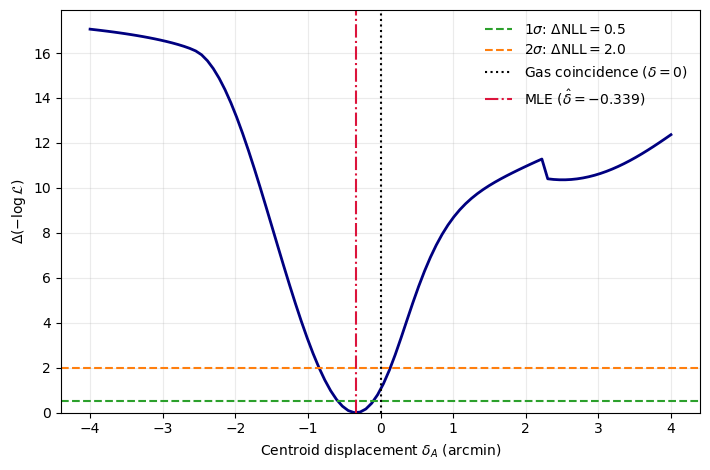

delta_hat = -0.338606 arcmin
1-sigma interval: [-0.581765, -0.104486] arcmin
2-sigma interval: [-0.846699, 0.134413] arcmin
delta=0 inside 1 sigma? False
delta=0 inside 2 sigma? True


In [106]:
# TODO 4.5
def profile_nll_part4(theta, delta):
    A1, sig1, A2, mu2, sig2 = theta
    model = model_2gauss(
        x_part4,
        A1,
        x1_SX + delta,
        sig1,
        A2,
        mu2,
        sig2,
    )
    return 0.5 * np.sum(
        ((kappa_part4 - model) / sigma_kappa_part4) ** 2
        + np.log(2 * np.pi * sigma_kappa_part4**2)
    )

theta_free = np.array(
    [popt_k[0], abs(popt_k[2]), popt_k[3], popt_k[4], abs(popt_k[5])]
)
profile_bounds = [(0, None), (1e-4, 10), (0, None), (0, 8), (1e-4, 10)]

delta_hat = popt_k[1] - x1_SX
nll_min = profile_nll_part4(theta_free, delta_hat)
delta_grid = np.linspace(-4, 4, 100)
profile_values = np.empty_like(delta_grid)
previous_solution = None

for i, delta in enumerate(delta_grid):
    starts = [theta_free]
    if previous_solution is not None:
        starts.append(previous_solution)

    fits = [
        minimize(
            profile_nll_part4,
            start,
            args=(delta,),
            method="L-BFGS-B",
            bounds=profile_bounds,
            options={"maxiter": 20000, "ftol": 1e-12, "gtol": 1e-9},
        )
        for start in starts
    ]
    best_fit = min(fits, key=lambda result: result.fun)
    if not best_fit.success:
        raise RuntimeError(f"Profile minimization failed at delta={delta:.3f}")
    profile_values[i] = best_fit.fun
    previous_solution = best_fit.x

delta_nll = np.maximum(profile_values - nll_min, 0.0)

def profile_interval(grid, values, threshold, center):
    shifted = values - threshold
    crossings = []
    for i in range(len(grid) - 1):
        if shifted[i] == 0:
            crossings.append(float(grid[i]))
        elif shifted[i] * shifted[i + 1] < 0:
            fraction = -shifted[i] / (shifted[i + 1] - shifted[i])
            crossings.append(float(grid[i] + fraction * (grid[i + 1] - grid[i])))
    left = [value for value in crossings if value <= center]
    right = [value for value in crossings if value >= center]
    return max(left), min(right)

ci_1sigma = profile_interval(delta_grid, delta_nll, 0.5, delta_hat)
ci_2sigma = profile_interval(delta_grid, delta_nll, 2.0, delta_hat)

from pathlib import Path
figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)
profile_figure = figure_dir / "part4_profile_likelihood.png"

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.plot(delta_grid, delta_nll, color="navy", linewidth=2)
ax.axhline(0.5, color="tab:green", linestyle="--", label=r"$1\sigma$: $\Delta\mathrm{NLL}=0.5$")
ax.axhline(2.0, color="tab:orange", linestyle="--", label=r"$2\sigma$: $\Delta\mathrm{NLL}=2.0$")
ax.axvline(0, color="black", linestyle=":", label=r"Gas coincidence ($\delta=0$)")
ax.axvline(delta_hat, color="crimson", linestyle="-.", label=rf"MLE ($\hat{{\delta}}={delta_hat:.3f}$)")
ax.set_xlabel(r"Centroid displacement $\delta_A$ (arcmin)")
ax.set_ylabel(r"$\Delta(-\log \mathcal{L})$")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(profile_figure, dpi=300, bbox_inches="tight")
plt.show()

print(f"delta_hat = {delta_hat:.6f} arcmin")
print(f"1-sigma interval: [{ci_1sigma[0]:.6f}, {ci_1sigma[1]:.6f}] arcmin")
print(f"2-sigma interval: [{ci_2sigma[0]:.6f}, {ci_2sigma[1]:.6f}] arcmin")
print(f"delta=0 inside 1 sigma? {ci_1sigma[0] <= 0 <= ci_1sigma[1]}")
print(f"delta=0 inside 2 sigma? {ci_2sigma[0] <= 0 <= ci_2sigma[1]}")


#### 4.6: Final statement

The decision about the joint hypothesis that both mass peaks follow the gas is
based on the gas-fixed LRT. The individual Z-tests show which sub-cluster drives
that result.


In [107]:
# TODO 4.6
A = part4_displacements["A"]
B = part4_displacements["B"]
gas_lrt = part4_lrt["Gas centroids"]

joint_decision = "reject" if gas_lrt["p"] < alpha else "fail to reject"
evidence = "evidence" if gas_lrt["p"] < alpha else "no evidence"
confidence = 100 * (1 - gas_lrt["p"])

final_statement = (
    "The lensing mass peaks are displaced from the gas peaks by "
    f"delta_A = {A['delta_gas']:.2f} +/- {A['sigma_delta_gas']:.2f} arcmin "
    f"({abs(A['Z_gas']):.2f} sigma significance) and "
    f"delta_B = {B['delta_gas']:.2f} +/- {B['sigma_delta_gas']:.2f} arcmin "
    f"({abs(B['Z_gas']):.2f} sigma significance). At alpha = {alpha:.2f}, "
    f"we {joint_decision} the hypothesis that all mass follows the gas. "
    f"This constitutes {evidence} for dark matter at the {confidence:.5f}% "
    "confidence level."
)
print(final_statement)


The lensing mass peaks are displaced from the gas peaks by delta_A = -0.34 +/- 0.24 arcmin (1.42 sigma significance) and delta_B = 1.25 +/- 0.25 arcmin (5.08 sigma significance). At alpha = 0.05, we reject the hypothesis that all mass follows the gas. This constitutes evidence for dark matter at the 99.99996% confidence level.


### Part 5 Mass Budget and Error Propagation

In [108]:
dx = 0.5
sigma_eps = 0.30

TODO 5.1

In [109]:
M_star = M_per_gal * np.sum(data["N_obs"])
M_gas = M_per_SX * dx * np.sum(data["SX"])
M_tot = M_per_kappa * dx * np.sum(data["kappa_obs"])


sigma_M_star = M_per_gal * np.sqrt(np.sum(data["sigma_N"]**2))
sigma_M_gas = M_per_SX * dx * np.sqrt(np.sum(data["sigma_SX"]**2))
sigma_M_tot = M_per_kappa * dx * np.sqrt(np.sum(data["sigma_kappa"]**2))

TODO 5.2

In [110]:
M_DM = M_tot - M_gas - M_star
f_DM = M_DM / M_tot

sigma_M_DM = np.sqrt(sigma_M_tot**2 + sigma_M_gas**2 + sigma_M_star**2)

# Propagación del error para la fracción usando el Método Delta
# f_DM = (M_tot - M_gas - M_star) / M_tot
df_dMtot = (M_gas + M_star) / (M_tot**2)
df_dMgas = -1.0 / M_tot
df_dMstar = -1.0 / M_tot

sigma_fDM = np.sqrt((df_dMtot * sigma_M_tot)**2 + 
                    (df_dMgas * sigma_M_gas)**2 + 
                    (df_dMstar * sigma_M_star)**2)

TODO 5.3

In [111]:
print(f"{'Component':<15} | {'Mass (M_sun)':<25} | {'Fraction':<10}")
print("-" * 55)
print(f"{'Stellar':<15} | ({M_star/1e14:.2f} ± {sigma_M_star/1e14:.2f}) x 10^14 | {M_star/M_tot * 100:>5.2f}%")
print(f"{'Gas':<15} | ({M_gas/1e14:.2f} ± {sigma_M_gas/1e14:.2f}) x 10^14 | {M_gas/M_tot * 100:>5.2f}%")
print(f"{'Dark matter':<15} | ({M_DM/1e14:.2f} ± {sigma_M_DM/1e14:.2f}) x 10^14 | {f_DM * 100:>5.2f}%")
print(f"{'Total':<15} | ({M_tot/1e14:.2f} ± {sigma_M_tot/1e14:.2f}) x 10^14 | 100.00%")

Component       | Mass (M_sun)              | Fraction  
-------------------------------------------------------
Stellar         | (0.72 ± 0.04) x 10^14 |  8.27%
Gas             | (0.08 ± 0.00) x 10^14 |  0.90%
Dark matter     | (7.95 ± 1.01) x 10^14 | 90.83%
Total           | (8.75 ± 1.00) x 10^14 | 100.00%


TODO 5.4

In [112]:
S = f_DM / sigma_fDM
print(f"\nSignificance of Dark Matter detection: S = {S:.2f} sigma")


Significance of Dark Matter detection: S = 79.61 sigma
